# Key gene set correlation

Compute donor-level curated gene-set scores from pseudobulk counts, then inspect Pearson/Spearman correlations between gene-set scores and within selected gene groups.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style='white', context='talk')


In [6]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PSEUDOBULK_DIR = PROJECT_ROOT / 'results' / '10_Pseudobulk_26donors'

PSEUDOBULK_LEVEL_DIRS = {
    'broad': PSEUDOBULK_DIR / 'broad',
    'glia_subtype': PSEUDOBULK_DIR / 'glia_subtypes',
    'excitatory_subtype': PSEUDOBULK_DIR / 'excitatory_subtypes',
}

## Settings

Choose either correlations across selected cell types within one condition, or correlations across selected conditions within one cell type.


In [25]:
GENE_SETS = {
    'CSW': ['C9ORF72', 'SMCR8', 'WDR41'],
    'ULK_complex': ['ULK1', 'ATG13', 'ATG101', 'RB1CC1'],
    'cGAS_STING': ['CGAS', 'STING1', 'TBK1', 'IRF3'],
    'Claw_interactors': ['CCPG1', 'ATG16L1', 'AZI2', 'TBKBP1', 'SQSTM1', 'NBR1', 'RETREG1', 'OPTN', 'SMCR8', 'TNIP1'],
}

GENE_GROUPS_FOR_INTERNAL_CORRELATION = {
    'SMCR8_FIP200': ['SMCR8', 'RB1CC1'],
    'CSW': ['C9ORF72', 'SMCR8', 'WDR41'],
    'ULK_complex': ['ULK1', 'ATG13', 'ATG101', 'RB1CC1'],
    'cGAS_STING': ['CGAS', 'STING1', 'TBK1', 'IRF3'],
}

GROUPING_LEVEL = 'glia_subtype'  # 'broad', 'glia_subtype', or 'excitatory_subtype'
# CELL_TYPES_TO_ANALYSE = ['Excitatory', 'Inhibitory', 'Glia']
CELL_TYPES_TO_ANALYSE = ['Glia_Micro', 'Glia_Oligo', 'Glia_Astro', 'Glia_OPC']
# CELL_TYPES_TO_ANALYSE = ['Ex_L5_PCP4_NXPH2', 'Ex_L5_L6_THEMIS_NR4A2', 'Ex_L5_L6_THEMIS_TMEM233', 'Ex_L6_TLE4_CCBE1', 'Ex_L6_TLE4_MEGF11']

ANALYSIS_MODE = 'cell_types_within_condition'  # or 'conditions_within_cell_type'
CONDITION_TO_ANALYSE = 'Control'

CELL_TYPE_TO_ANALYSE = 'Excitatory'
CONDITIONS_TO_ANALYSE = ['Control', 'sALS', 'c9ALS']

CORRELATION_METHODS = ['spearman'] # alternatively, 'pearson'
MIN_DONORS = 3
N_COLS = 3


## Load pseudobulk counts


In [26]:
input_dir = PSEUDOBULK_LEVEL_DIRS[GROUPING_LEVEL]
groups_to_load = CELL_TYPES_TO_ANALYSE if ANALYSIS_MODE == 'cell_types_within_condition' else [CELL_TYPE_TO_ANALYSE]

counts_list = []
meta_list = []

for cell_type in groups_to_load:
    counts_path = input_dir / f'{cell_type}_counts.csv'
    meta_path = input_dir / f'{cell_type}_meta.csv'

    if not counts_path.exists() or not meta_path.exists():
        print(f'Missing pseudobulk for {cell_type}; skipped.')
        continue

    counts_i = pd.read_csv(counts_path, index_col=0)
    meta_i = pd.read_csv(meta_path)

    # Pseudobulk metadata should contain sample IDs. Keep them explicit so
    # downstream donor counts never depend on pandas index-reset behaviour.
    if 'sample' not in meta_i.columns:
        first_col = meta_i.columns[0]
        meta_i = meta_i.rename(columns={first_col: 'sample'})

    counts_i.index = counts_i.index.astype(str)
    meta_i['sample'] = meta_i['sample'].astype(str)

    common_samples = counts_i.index.intersection(meta_i['sample'])
    if common_samples.empty:
        print(f'No matching sample IDs for {cell_type}; skipped.')
        continue

    counts_i = counts_i.loc[common_samples]
    meta_i = meta_i.set_index('sample').loc[common_samples].copy()
    meta_i.insert(0, 'sample', common_samples.astype(str))
    meta_i['cell_type'] = cell_type

    profile_id = pd.Index([f'{cell_type}|{sample}' for sample in common_samples], name='profile_id')
    counts_i.index = profile_id
    meta_i.index = profile_id

    counts_list.append(counts_i)
    meta_list.append(meta_i)

if not counts_list:
    raise ValueError('No pseudobulk inputs were loaded.')

counts = pd.concat(counts_list, axis=0)
meta = pd.concat(meta_list, axis=0)
counts = counts.loc[meta.index]

print(f'Loaded {counts.shape[0]} donor x cell-type pseudobulk profiles and {counts.shape[1]} genes.')
display(meta.groupby(['cell_type', 'condition']).size().unstack(fill_value=0))


Loaded 104 donor x cell-type pseudobulk profiles and 61552 genes.


condition,Control,c9ALS,sALS
cell_type,,,
Glia_Astro,10,6,10
Glia_Micro,10,6,10
Glia_OPC,10,6,10
Glia_Oligo,10,6,10


## Match genes and compute donor-level scores


In [27]:
gene_lookup = {gene.upper(): gene for gene in counts.columns.astype(str)}
requested_genes = sorted({gene for genes in GENE_SETS.values() for gene in genes} | {gene for genes in GENE_GROUPS_FOR_INTERNAL_CORRELATION.values() for gene in genes})
gene_map = {gene: gene_lookup[gene.upper()] for gene in requested_genes if gene.upper() in gene_lookup}

gene_availability = pd.DataFrame({
    'requested_gene': requested_genes,
    'matched_gene': [gene_map.get(gene, pd.NA) for gene in requested_genes],
    'available': [gene in gene_map for gene in requested_genes],
})
display(gene_availability)

matched_gene_sets = {
    name: [gene for gene in genes if gene in gene_map]
    for name, genes in GENE_SETS.items()
}
matched_gene_sets = {name: genes for name, genes in matched_gene_sets.items() if genes}

counts_float = counts.astype(float)
library_size = counts_float.sum(axis=1).replace(0, np.nan)
logcpm = np.log1p(counts_float.div(library_size, axis=0).mul(1e6)).fillna(0.0)

gene_set_scores = meta[['sample', 'condition', 'cell_type']].copy()
for set_name, genes in matched_gene_sets.items():
    matched_cols = [gene_map[gene] for gene in genes]
    z = logcpm[matched_cols].apply(lambda x: (x - x.mean()) / x.std(ddof=0), axis=0).replace([np.inf, -np.inf], np.nan)
    gene_set_scores[set_name] = z.mean(axis=1)

display(gene_set_scores.head())


,requested_gene,matched_gene,available
0,ATG101,ATG101,True
1,ATG13,ATG13,True
2,ATG16L1,ATG16L1,True
3,AZI2,AZI2,True
4,C9ORF72,C9orf72,True
5,CCPG1,CCPG1,True
6,CGAS,CGAS,True
7,IRF3,IRF3,True
8,NBR1,NBR1,True
9,OPTN,OPTN,True


,sample,condition,cell_type,CSW,ULK_complex,cGAS_STING,Claw_interactors
profile_id,,,,,,,
Glia_Micro|GSM5292143,GSM5292143,sALS,Glia_Micro,0.969054,-0.023770,1.605978,-0.160454
Glia_Micro|GSM5292144,GSM5292144,sALS,Glia_Micro,0.040855,-2.624108,1.715330,-1.996675
Glia_Micro|GSM5292145,GSM5292145,sALS,Glia_Micro,0.934115,-0.194527,1.269907,-0.040124
Glia_Micro|GSM5292146,GSM5292146,c9ALS,Glia_Micro,1.119784,0.198469,1.486980,0.497549
Glia_Micro|GSM5292147,GSM5292147,c9ALS,Glia_Micro,0.671775,-1.103309,1.569060,0.047917


## Correlation helpers


In [18]:
def corr_and_p(x, y, method):
    xy = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(xy) < MIN_DONORS or xy['x'].nunique() < 2 or xy['y'].nunique() < 2:
        return np.nan, np.nan
    return spearmanr(xy['x'], xy['y']) if method == 'spearman' else pearsonr(xy['x'], xy['y'])


def iter_scopes(df):
    if ANALYSIS_MODE == 'cell_types_within_condition':
        for cell_type in CELL_TYPES_TO_ANALYSE:
            scope = df[df['condition'].astype(str).eq(CONDITION_TO_ANALYSE) & df['cell_type'].astype(str).eq(cell_type)]
            yield f'{cell_type} | {CONDITION_TO_ANALYSE}', cell_type, CONDITION_TO_ANALYSE, scope
    else:
        for condition in CONDITIONS_TO_ANALYSE:
            scope = df[df['cell_type'].astype(str).eq(CELL_TYPE_TO_ANALYSE) & df['condition'].astype(str).eq(condition)]
            yield f'{CELL_TYPE_TO_ANALYSE} | {condition}', CELL_TYPE_TO_ANALYSE, condition, scope


def plot_heatmap_panel(matrices, title):
    if not matrices:
        print(f'No matrices to plot for {title}.')
        return
    n_panels = len(matrices)
    n_cols = min(N_COLS, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.8 * n_rows), constrained_layout=True)
    axes = np.asarray(axes).ravel()

    for ax, (scope_label, matrix, n_donors) in zip(axes, matrices):
        matrix = matrix.copy()
        np.fill_diagonal(matrix.values, np.nan)
        sns.heatmap(matrix, cmap='vlag', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', square=True, ax=ax, cbar=n_panels == 1)
        ax.set_title(f'{scope_label}\nn={n_donors}', fontsize=10, pad=8)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)

    for ax in axes[n_panels:]:
        ax.remove()
    fig.suptitle(title, fontsize=14)
    plt.show()


## Gene-set score correlations


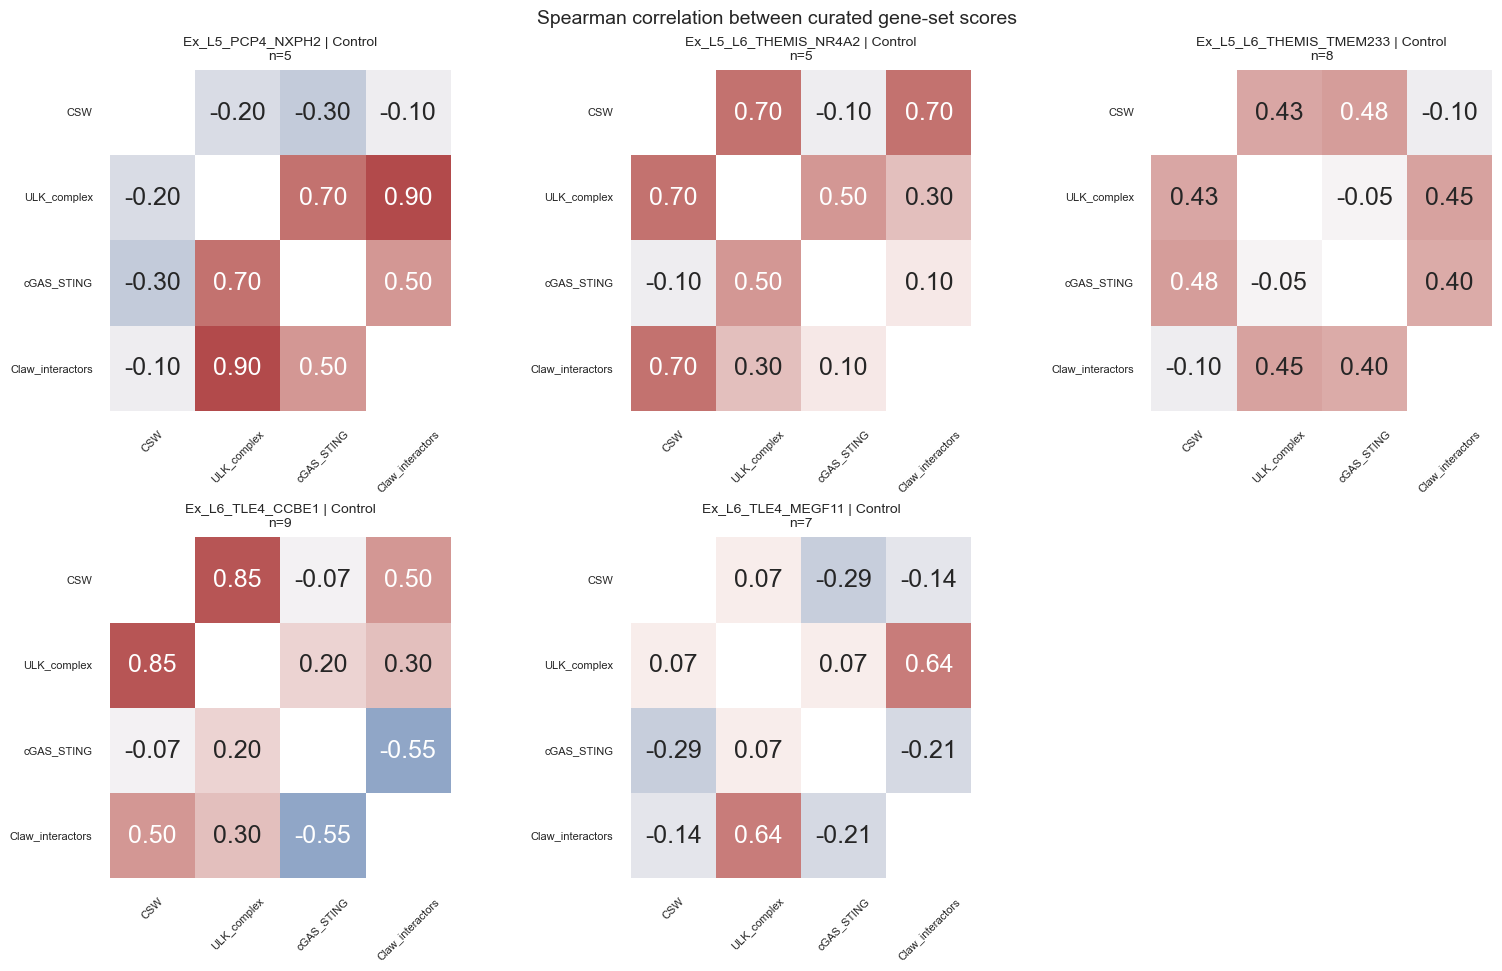

In [23]:
gene_set_names = list(matched_gene_sets)

for method in CORRELATION_METHODS:
    matrices = []
    for scope_label, cell_type, condition, scope in iter_scopes(gene_set_scores):
        n_donors = scope['sample'].nunique()
        if n_donors < MIN_DONORS:
            continue
        corr = pd.DataFrame(np.nan, index=gene_set_names, columns=gene_set_names)
        for x in gene_set_names:
            for y in gene_set_names:
                corr.loc[x, y], _ = corr_and_p(scope[x], scope[y], method)
        matrices.append((scope_label, corr, n_donors))
    plot_heatmap_panel(matrices, f'{method.capitalize()} correlation between curated gene-set scores')


## Internal gene correlations within selected groups


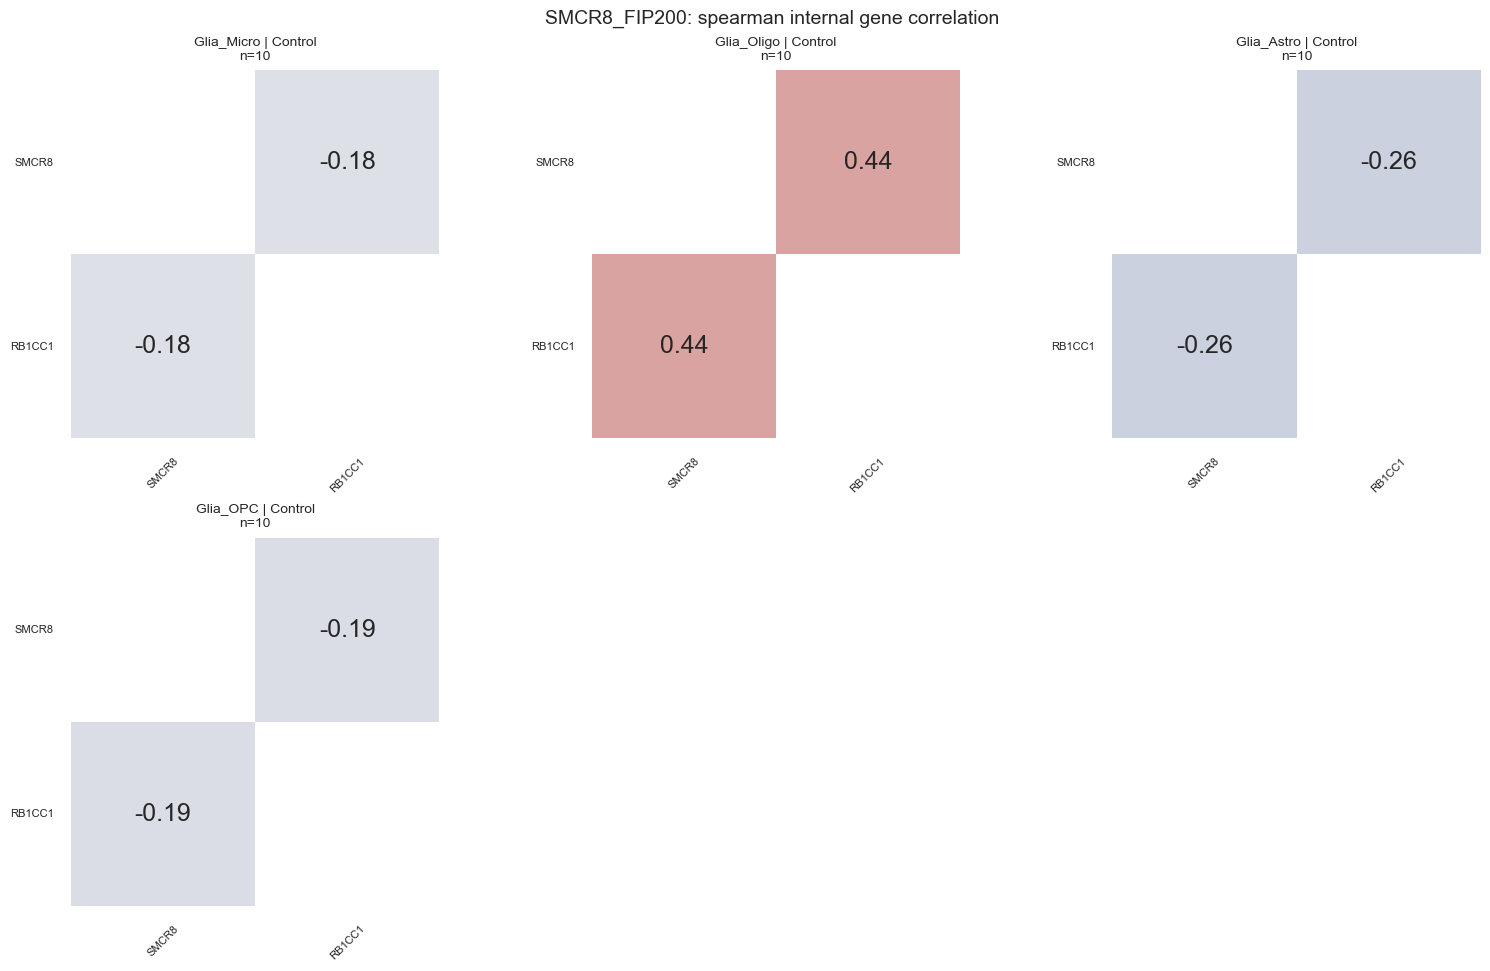

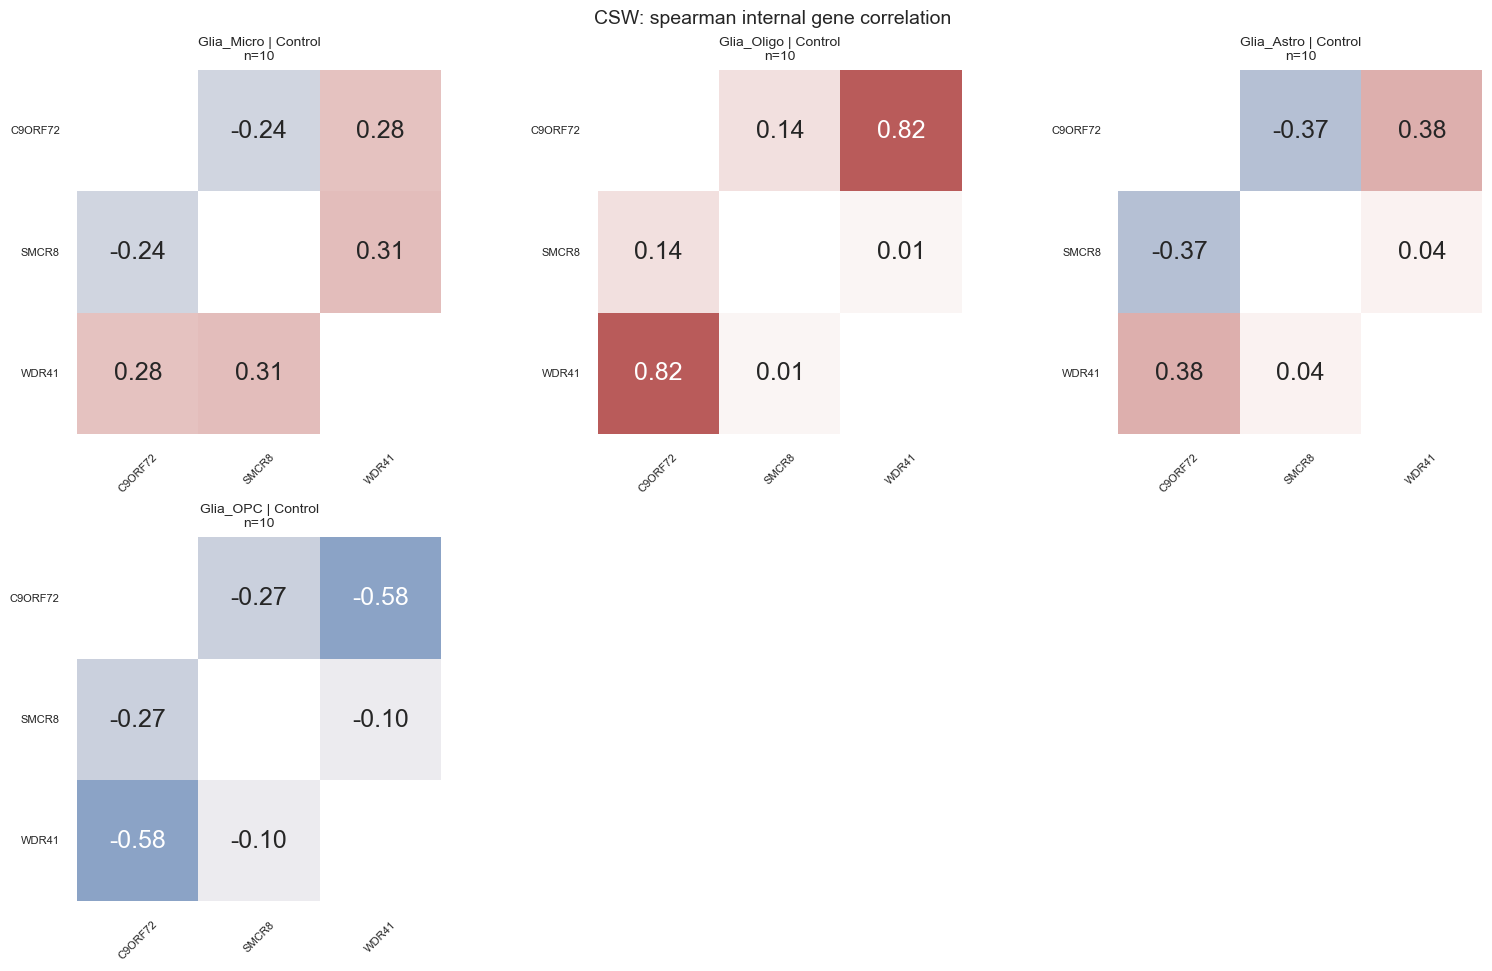

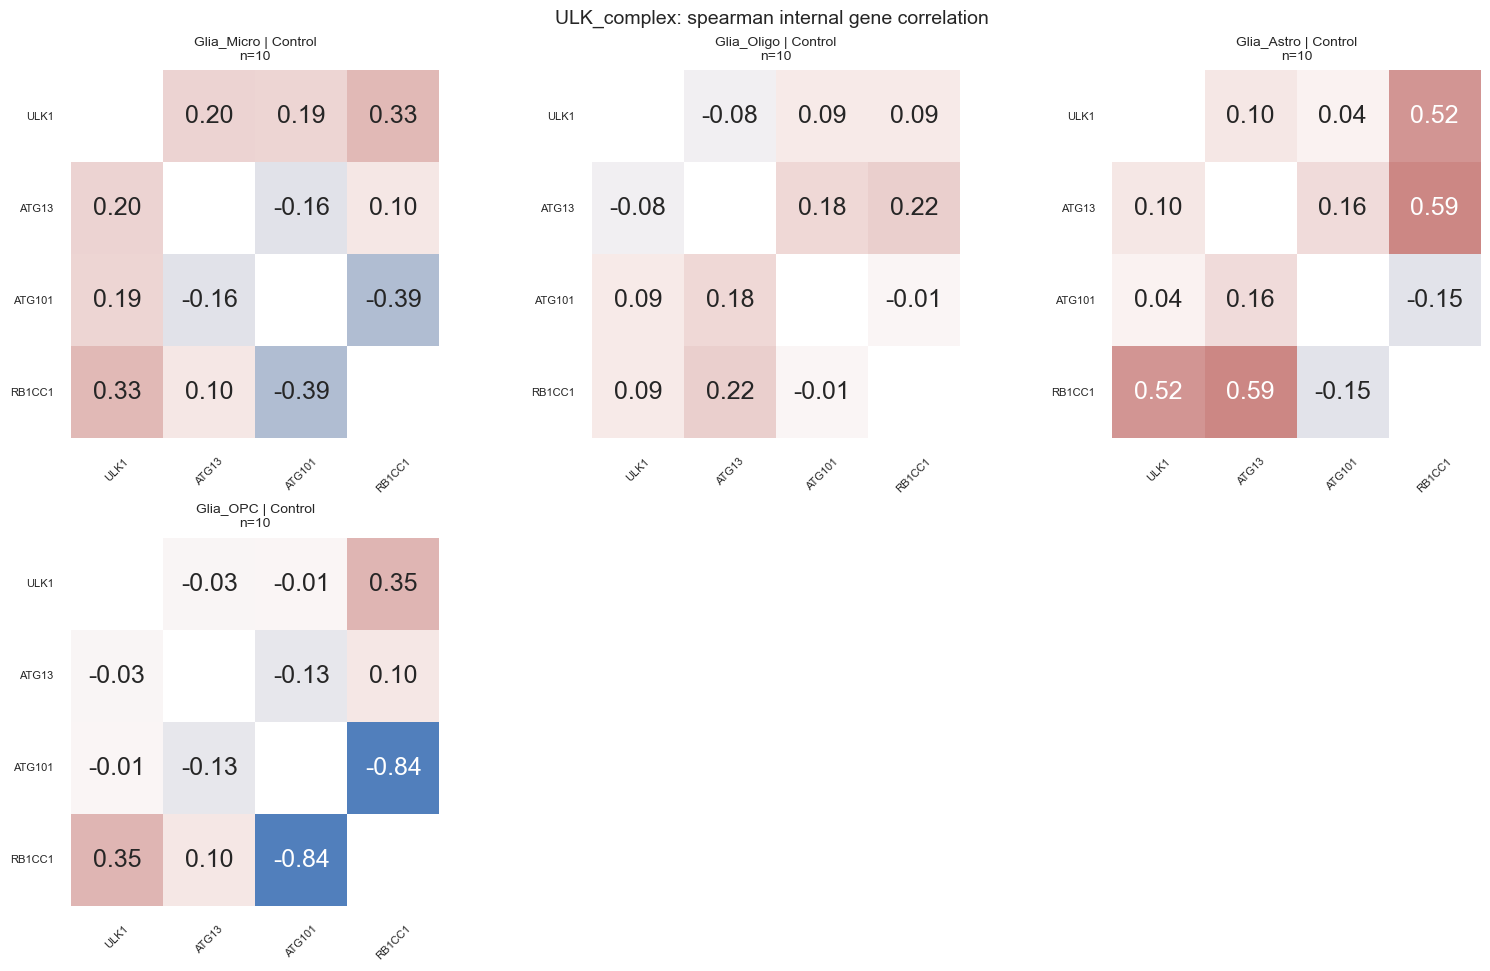

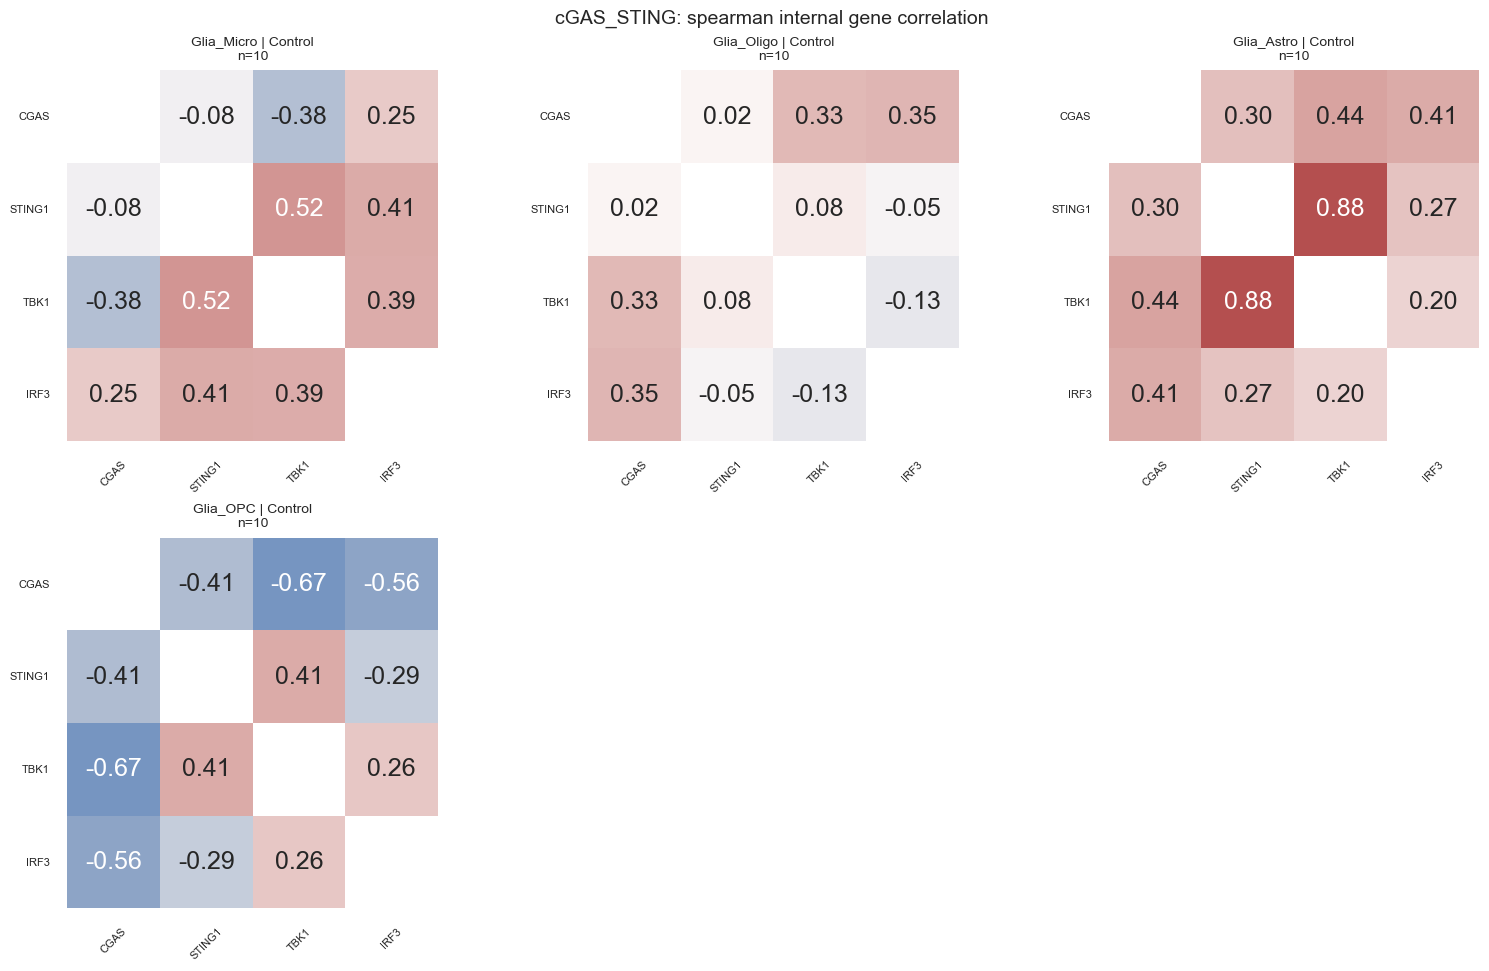

In [28]:
gene_values = meta[['sample', 'condition', 'cell_type']].copy()
for requested_gene, matched_gene in gene_map.items():
    gene_values[requested_gene] = logcpm[matched_gene]

for group_name, genes in GENE_GROUPS_FOR_INTERNAL_CORRELATION.items():
    genes = [gene for gene in genes if gene in gene_map]
    if len(genes) < 2:
        continue
    for method in CORRELATION_METHODS:
        matrices = []
        for scope_label, cell_type, condition, scope in iter_scopes(gene_values):
            n_donors = scope['sample'].nunique()
            if n_donors < MIN_DONORS:
                continue
            corr = pd.DataFrame(np.nan, index=genes, columns=genes)
            for x in genes:
                for y in genes:
                    corr.loc[x, y], _ = corr_and_p(scope[x], scope[y], method)
            matrices.append((scope_label, corr, n_donors))
        plot_heatmap_panel(matrices, f'{group_name}: {method} internal gene correlation')


## Donor-level scatter plots for key correlations

These plots show whether a correlation is supported by the donor cloud or driven by one unusual donor.


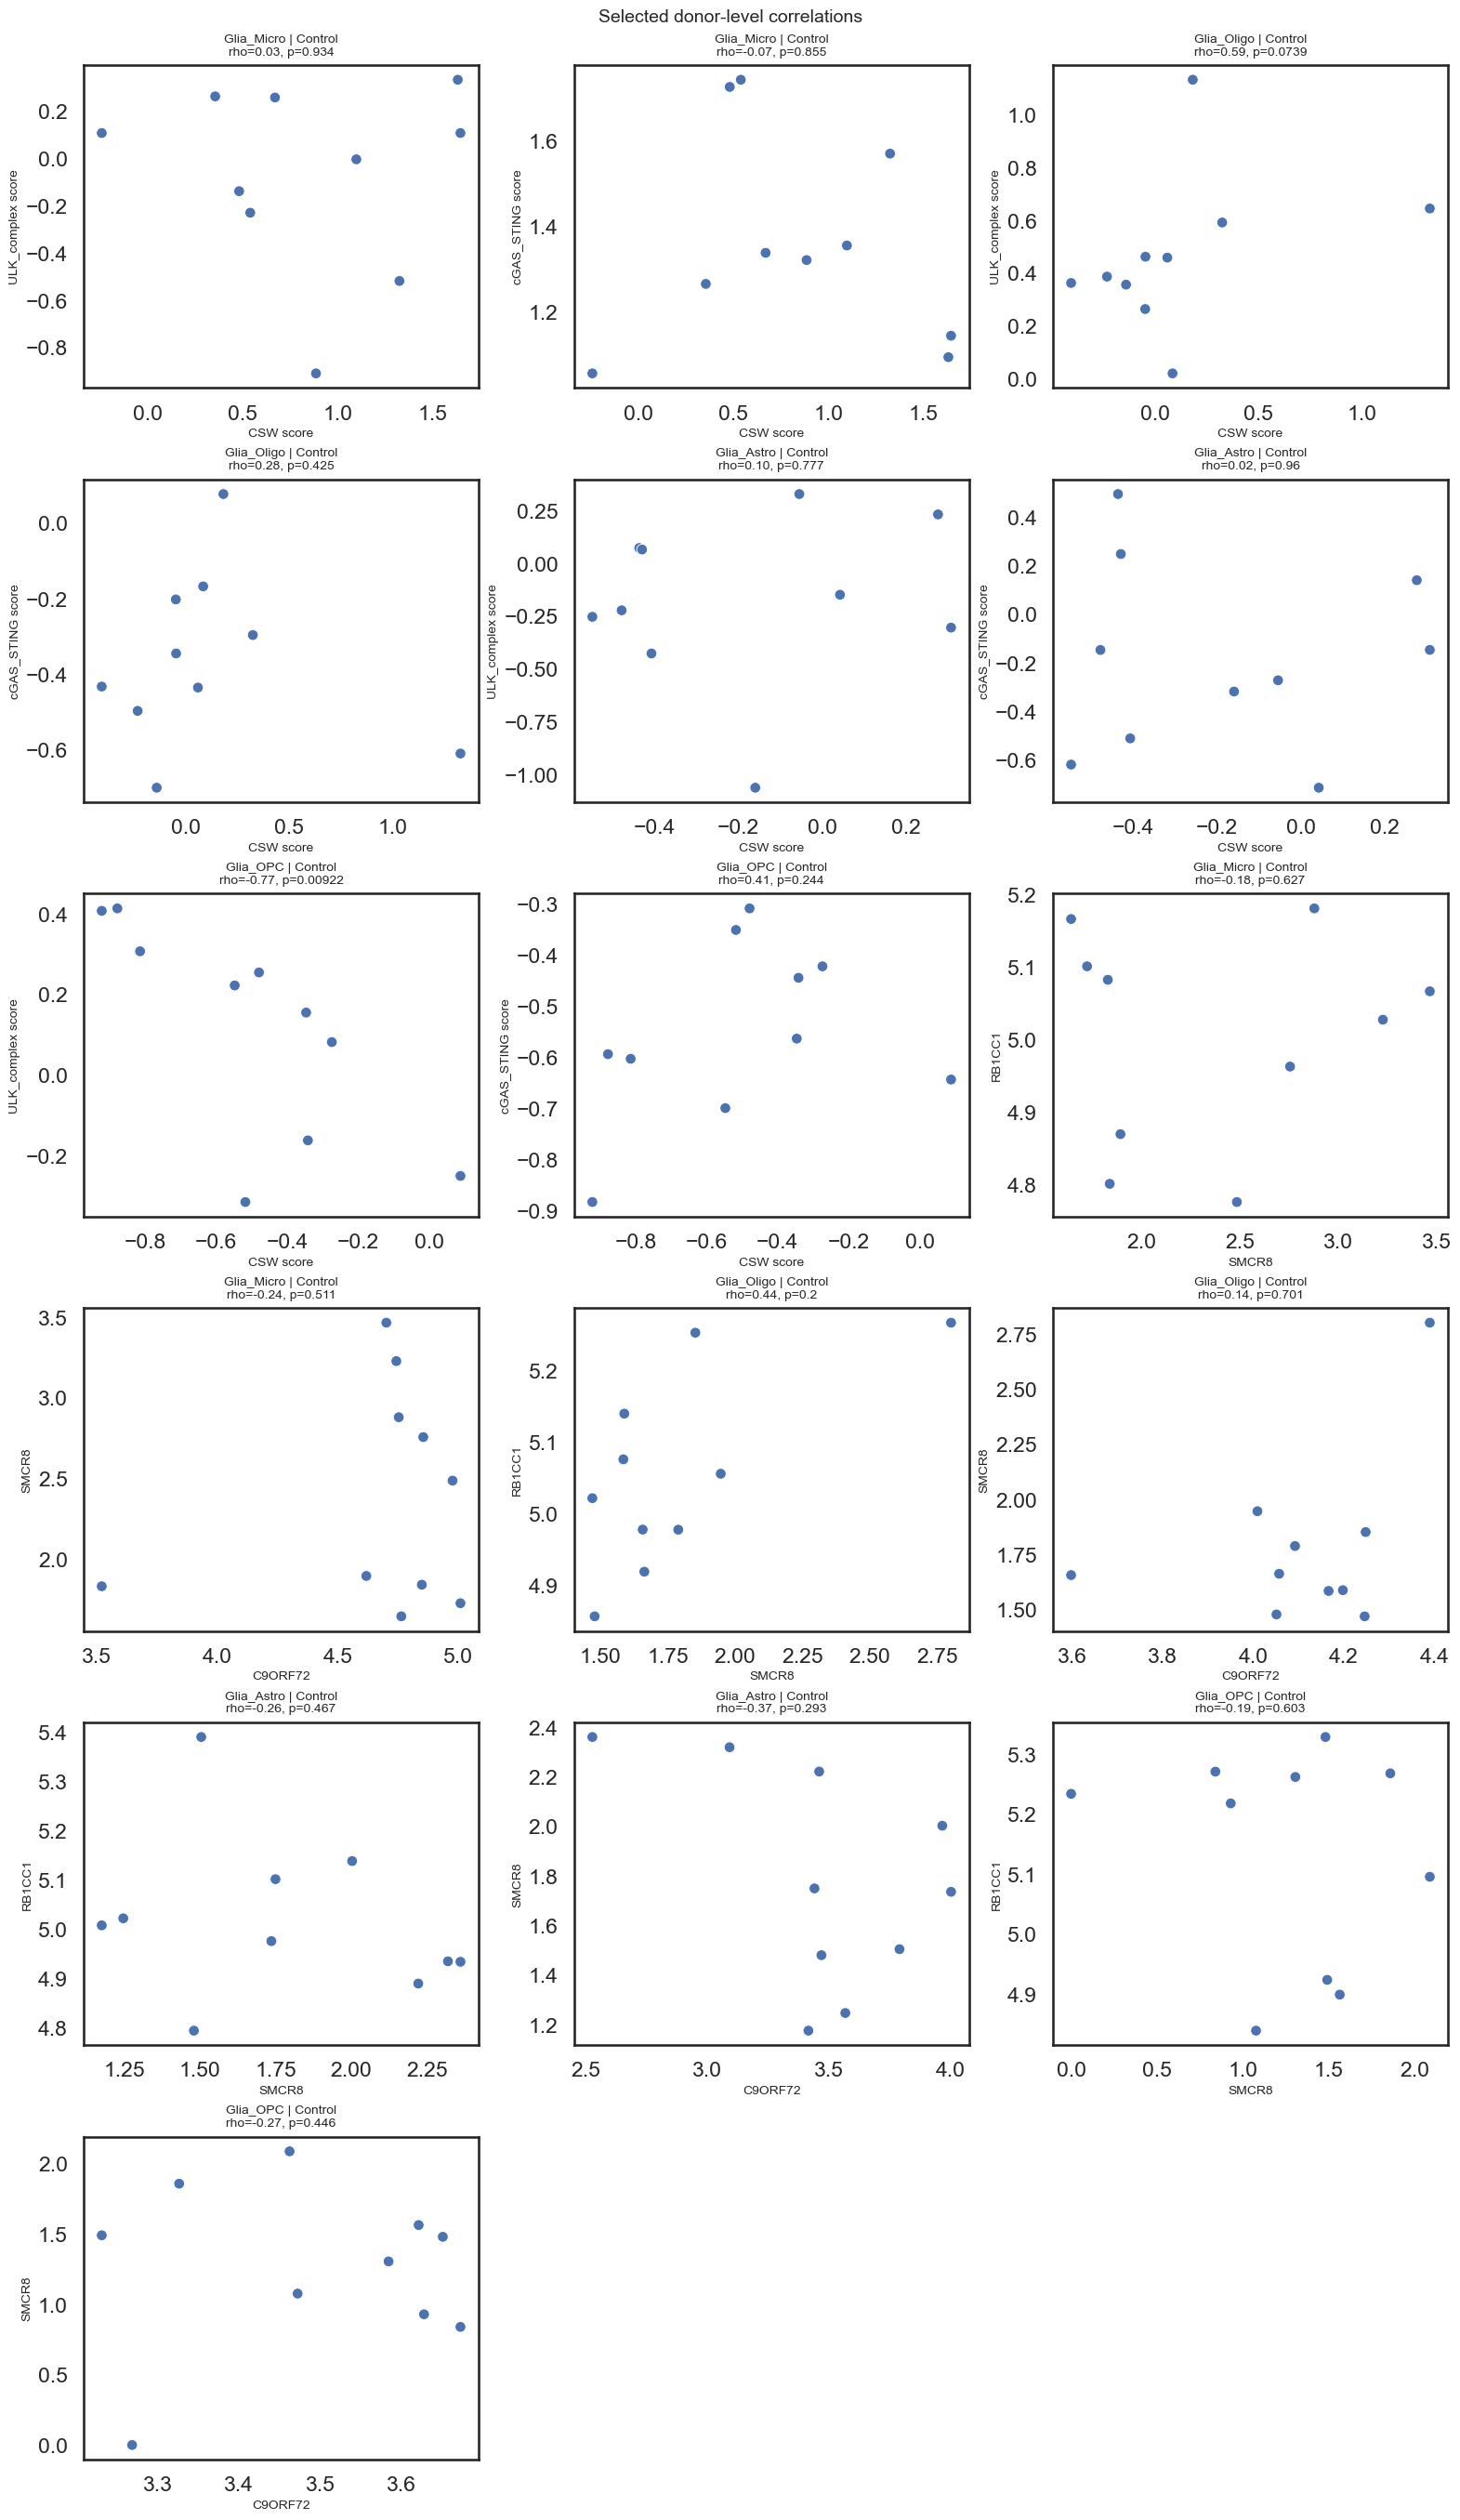

In [29]:
GENE_SET_SCATTERS = [('CSW', 'ULK_complex'), ('CSW', 'cGAS_STING')]
GENE_SCATTERS = [('SMCR8', 'RB1CC1'), ('C9ORF72', 'SMCR8')]
SCATTER_METHOD = 'spearman'

scatter_specs = []
for scope_label, cell_type, condition, scope in iter_scopes(gene_set_scores):
    if scope['sample'].nunique() < MIN_DONORS:
        continue
    for x, y in GENE_SET_SCATTERS:
        if x in scope and y in scope:
            scatter_specs.append((scope_label, f'{x} score', f'{y} score', scope, x, y))

for scope_label, cell_type, condition, scope in iter_scopes(gene_values):
    if scope['sample'].nunique() < MIN_DONORS:
        continue
    for x, y in GENE_SCATTERS:
        if x in scope and y in scope:
            scatter_specs.append((scope_label, x, y, scope, x, y))

n_panels = len(scatter_specs)
if n_panels:
    n_cols = min(N_COLS, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.5 * n_rows), constrained_layout=True)
    axes = np.asarray(axes).ravel()

    for ax, (scope_label, x_label, y_label, scope, x, y) in zip(axes, scatter_specs):
        r, p = corr_and_p(scope[x], scope[y], SCATTER_METHOD)
        sns.scatterplot(data=scope, x=x, y=y, hue='condition', style='cell_type', s=70, ax=ax, legend=False)
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_title(f'{scope_label}\nrho={r:.2f}, p={p:.3g}', fontsize=10, pad=8)
    for ax in axes[n_panels:]:
        ax.remove()
    fig.suptitle('Selected donor-level correlations', fontsize=14)
    plt.show()
else:
    print('No scatter plots available for the current settings.')
